# Taylor diagrams

## Introduction

Taylor diagrams provide a compact graphical summary of the skill of model simulations in reproducing observed spatial patterns, by simultaneously representing the spatial correlation, the standard deviation, and the centered root-mean-square difference with respect to a reference dataset. In this study, they are used to assess the ability of EURO-CORDEX simulations to capture the spatial structure of Fire Weather Index (FWI) climatology and its upper-tail behaviour (FWI95), as represented by ERA5-Land. 

By condensing multiple performance metrics into a single framework, Taylor diagrams allow for a direct intercomparison of models in terms of both pattern fidelity and amplitude of variability. This is particularly useful in the context of fire weather analysis, where accurately reproducing the spatial gradients and contrasts of both mean conditions and extremes is essential for understanding regional differences in fire risk across Europe.

### Note on target season

For illustrative purposes, the analysis shown in this notebook is restricted to the **JJA** season. This choice is motivated by the fact that fire weather conditions over Europe are most relevant during summer, when the combined effects of high temperatures, low humidity and sustained dry conditions lead to enhanced FWI values and increased fire risk. Focusing on this period allows us to highlight the spatial variability and model performance under the most dynamically active and impactful regime of the index, avoiding dilution of the signal by seasons with systematically low or negligible fire weather activity.


### Taylor diagram implementation
Taylor diagrams were implemented using the `taylor.diagram` function from the `plotrix` R package. This implementation provides a straightforward framework to compute and display the key summary statistics (correlation coefficient, standard deviation and centered root-mean-square difference) for each model relative to a specified reference field. The function allows for flexible customization of graphical elements (e.g., reference standard deviation, axes limits, and labeling), facilitating a consistent visual comparison of multiple EURO-CORDEX simulations within a single diagram.

In [ ]:
library(transformeR) ## climate4R package for climate data manipulation and analysis
library(plotrix) ## A nice and versatile Taylor diagram implementation
library(magrittr)

## Load ERA5-Land reference dataset

FWI reference data is loaded. For efficiency, monthly means are already pre-computed, both for teh ERA5-Land reference and for the RCM simulations.

In [8]:
load("/mnt/CORDEX_CMIP6_tmp/user_tmp/jbediajimenez/fwi_val_results/monthly_bias/monthly_data/ERA5-Land_fwi_monthly.Rdata", verbose = TRUE)
fwi.ref <- monthly_fwi
fwi.ref.jja <- subsetGrid(fwi.ref, season = 6:8)

Loading objects:
  monthly_fwi


Monthly FWI 95th percentile fields are also pre-calculated:

In [9]:
load("/mnt/CORDEX_CMIP6_tmp/user_tmp/jbediajimenez/fwi_val_results/monthly_bias/monthly_data/ERA5-Land_fwi95_monthly.Rdata", verbose = TRUE)
fwi95.ref <- monthly_fwi95
fwi95.ref.jja <- subsetGrid(fwi95.ref, season = 6:8)

Loading objects:
  monthly_fwi95


## Load RCM FWI datasets

We compute first mean FWI Taylor diagrams:

In [31]:
lf <- list.files("/mnt/CORDEX_CMIP6_tmp/user_tmp/jbediajimenez/fwi_val_results/monthly_bias/monthly_data/", full.names = TRUE)
model.list.fwi <- lf[grep("ERA5-Land|fwi95", lf, invert = TRUE)]

From the file paths, we extract a vector of unique RCM identifiers 

In [32]:
(rcm.names <- gsub("_fwi.*", "", basename(model.list.fwi)))

[1] "CLMcom-CMCC_CCLM6-0-1-URB"         "CLMcom-Hereon_CCLM6-0-1"          
 [3] "CLMcom-Hereon_GCOAST-AHOIB1-1"     "CLMcom-Hereon_ICON-CLM-202407-1-1"
 [5] "CLMcom-KUL_CCLM6-0-1-URB-ESG"      "CNRM_ALADIN64E1"                  
 [7] "DWD-BSH_ROAM-NBS"                  "GERICS_REMO2020-2-2-iMOVE"        
 [9] "GERICS_REMO2020-2-2-iMOVE-LUC"     "GERICS_REMO2020-2-2-TEB"          
[11] "HCLIMcom-SMHI_HCLIM43-ALADIN"      "ICTP_RegCM5-0"                    
[13] "IDL-FCUL_WRF451Q"                  "KNMI_RACMO23E"                    
[15] "RMIUB-UGent_ALARO1-SFX"

Models are loaded and JJA season is extracted:

[2026-06-05 11:40:32.804608] Processing CLMcom-CMCC_CCLM6-0-1-URB



[2026-06-05 11:40:42.681922] Processing CLMcom-Hereon_CCLM6-0-1

[2026-06-05 11:40:53.778722] Processing CLMcom-Hereon_GCOAST-AHOIB1-1

[2026-06-05 11:41:04.174567] Processing CLMcom-Hereon_ICON-CLM-202407-1-1

[2026-06-05 11:41:15.611409] Processing CLMcom-KUL_CCLM6-0-1-URB-ESG

[2026-06-05 11:41:25.979078] Processing CNRM_ALADIN64E1

[2026-06-05 11:41:35.599277] Processing DWD-BSH_ROAM-NBS

[2026-06-05 11:41:47.561014] Processing GERICS_REMO2020-2-2-iMOVE

[2026-06-05 11:41:59.861611] Processing GERICS_REMO2020-2-2-iMOVE-LUC

[2026-06-05 11:42:11.180617] Processing GERICS_REMO2020-2-2-TEB

[2026-06-05 11:42:22.284261] Processing HCLIMcom-SMHI_HCLIM43-ALADIN

[2026-06-05 11:42:34.093636] Processing ICTP_RegCM5-0

[2026-06-05 11:42:45.728948] Processing IDL-FCUL_WRF451Q

[2026-06-05 11:42:57.180023] Processing KNMI_RACMO23E

[2026-06-05 11:43:08.861675] Processing RMIUB-UGent_ALARO1-SFX



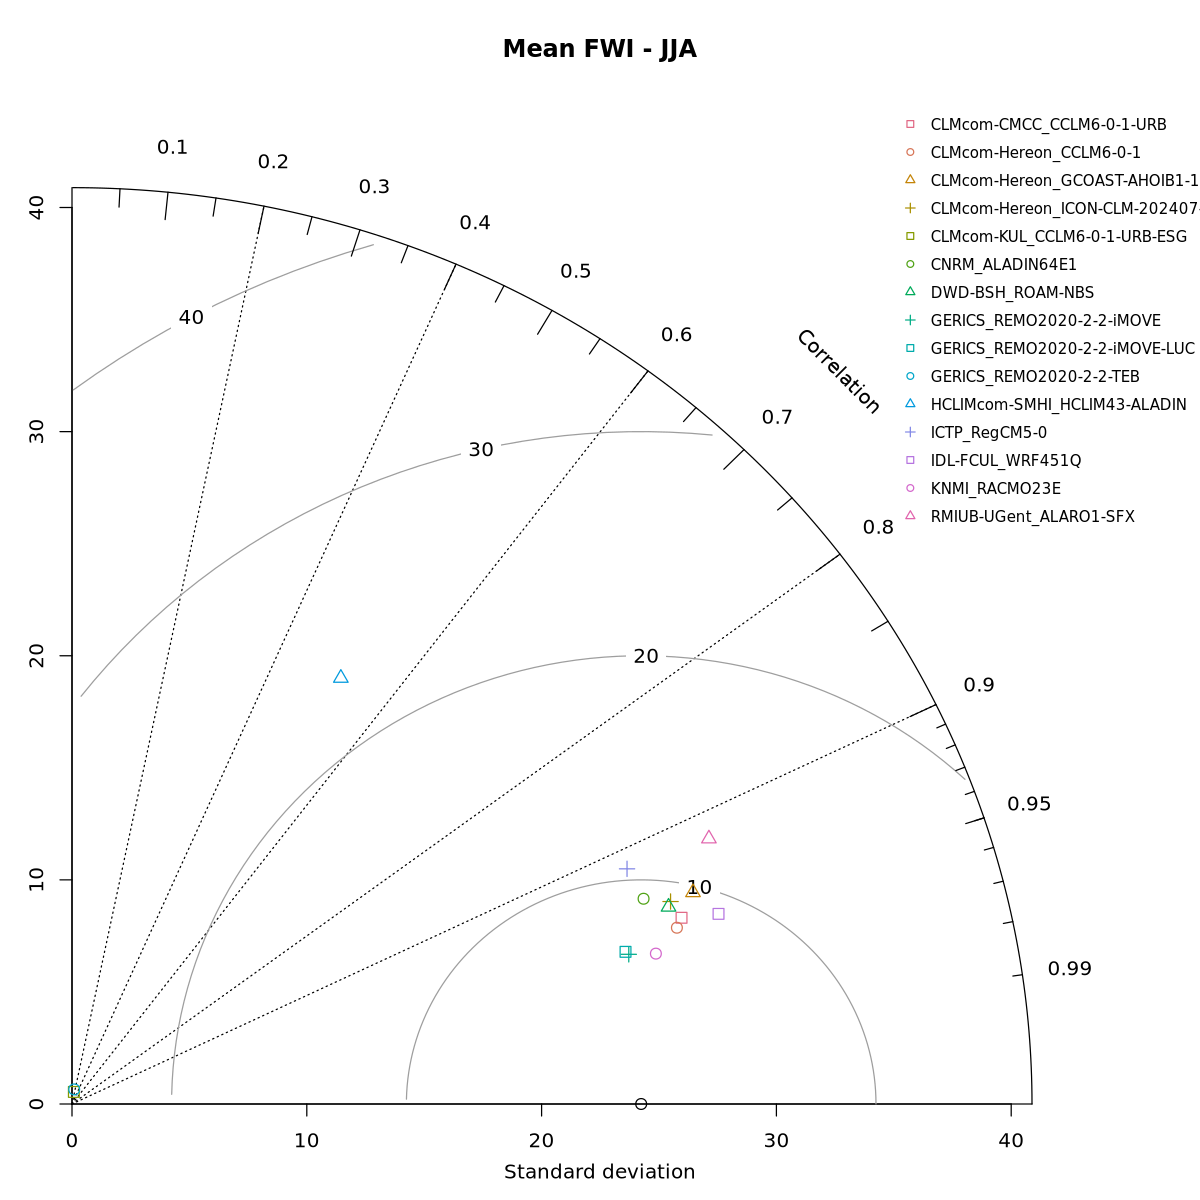

In [33]:
options(repr.plot.width = 10, repr.plot.height = 10)

oldpar <- par(no.readonly = TRUE)
par(mar = c(4, 4, 2, 12), xpd = NA)  # más margen a la derecha
cols <- grDevices::hcl.colors(length(model.list.fwi), palette = "Dark 3")
pch_pt <- rep(c(0,1,2,3), length.out = length(model.list.fwi))
pcex <- 1.2

for (i in seq_along(model.list.fwi)) {
    message("[", Sys.time(), "] Processing ", rcm.names[i])
    load(model.list.fwi[i])

    yrs <- getYearsAsINDEX(monthly_fwi) %>% unique()
    model.jja <- subsetGrid(monthly_fwi, season = 6:8)
    ref.jja <- subsetGrid(fwi.ref.jja, years = yrs) # por si faltan 2019-2020 (e.g. GCOAST)

    if (i == 1L) {
        taylor.diagram(ref = as.vector(ref.jja$Data),
                       model = as.vector(model.jja$Data),
                       add = FALSE,
                       col = cols[i],
                       pch = pch_pt[i],
                       pcex = pcex,
                       main = "Mean FWI - JJA")
    } else {
        taylor.diagram(ref = as.vector(ref.jja$Data),
                       model = as.vector(model.jja$Data),
                       add = TRUE,
                       pch = pch_pt[i],
                       pcex = pcex,
                       col = cols[i])
    }
}

legend("topright",
       inset = c(-.25, 0), # desplaza la leyenda fuera del panel
       legend = rcm.names,
       col = cols,
       pch = pch_pt,
       bty = "n",
       cex = 0.75,
       xpd = NA
)

Same for FWI95

In [34]:
lf <- list.files("/mnt/CORDEX_CMIP6_tmp/user_tmp/jbediajimenez/fwi_val_results/monthly_bias/monthly_data/", full.names = TRUE)
model.list.fwi95 <- lf[grep("ERA5-Land|fwi_monthly", lf, invert = TRUE)]
rcm.names <- gsub("_fwi95.*", "", basename(model.list.fwi95))

[2026-06-05 11:43:21.382858] Processing CLMcom-CMCC_CCLM6-0-1-URB



[2026-06-05 11:43:30.381586] Processing CLMcom-Hereon_CCLM6-0-1

[2026-06-05 11:43:41.101463] Processing CLMcom-Hereon_GCOAST-AHOIB1-1

[2026-06-05 11:43:51.355862] Processing CLMcom-Hereon_ICON-CLM-202407-1-1

[2026-06-05 11:44:01.800516] Processing CLMcom-KUL_CCLM6-0-1-URB-ESG

[2026-06-05 11:44:11.327037] Processing CNRM_ALADIN64E1

[2026-06-05 11:44:21.687698] Processing DWD-BSH_ROAM-NBS

[2026-06-05 11:44:31.384441] Processing GERICS_REMO2020-2-2-iMOVE

[2026-06-05 11:44:41.062834] Processing GERICS_REMO2020-2-2-iMOVE-LUC

[2026-06-05 11:44:50.726371] Processing GERICS_REMO2020-2-2-TEB

[2026-06-05 11:45:00.44048] Processing HCLIMcom-SMHI_HCLIM43-ALADIN

[2026-06-05 11:45:10.076506] Processing ICTP_RegCM5-0

[2026-06-05 11:45:19.478227] Processing IDL-FCUL_WRF451Q

[2026-06-05 11:45:29.200001] Processing KNMI_RACMO23E

[2026-06-05 11:45:39.063796] Processing RMIUB-UGent_ALARO1-SFX



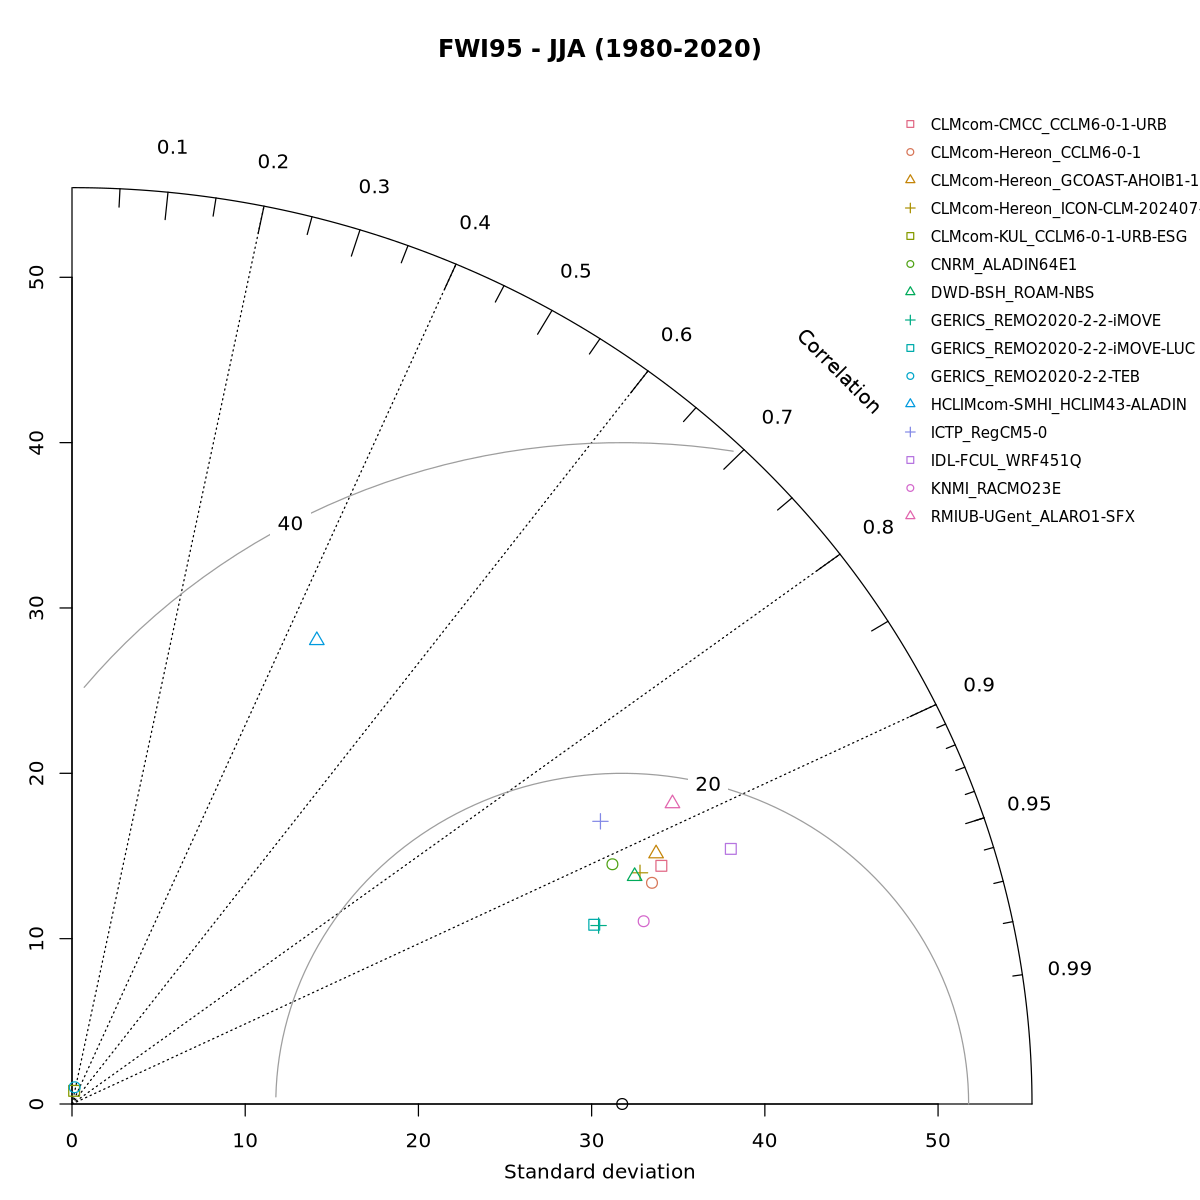

In [35]:
options(repr.plot.width = 10, repr.plot.height = 10)

oldpar <- par(no.readonly = TRUE)
par(mar = c(4, 4, 2, 12), xpd = NA)  # más margen a la derecha
cols <- grDevices::hcl.colors(length(model.list.fwi), palette = "Dark 3")
pch_pt <- rep(c(0,1,2,3), length.out = length(model.list.fwi95))
pcex <- 1.2

for (i in seq_along(model.list.fwi95)) {
    message("[", Sys.time(), "] Processing ", rcm.names[i])
    load(model.list.fwi95[i])

    yrs <- getYearsAsINDEX(monthly_fwi95) %>% unique()
    model.jja <- subsetGrid(monthly_fwi95, season = 6:8)
    ref.jja <- subsetGrid(fwi95.ref.jja, years = yrs) # por si faltan 2019-2020

    if (i == 1L) {
        taylor.diagram(ref = as.vector(ref.jja$Data),
                       model = as.vector(model.jja$Data),
                       add = FALSE,
                       col = cols[i],
                       pch = pch_pt[i],
                       pcex = pcex,
                       main = "FWI95 - JJA (1980-2020)")
    } else {
        taylor.diagram(ref = as.vector(ref.jja$Data),
                       model = as.vector(model.jja$Data),
                       add = TRUE,
                       pch = pch_pt[i],
                       pcex = pcex,
                       col = cols[i])
    }
}

legend("topright",
       inset = c(-.25, 0), # desplaza la leyenda fuera del panel
       legend = rcm.names,
       col = cols,
       pch = pch_pt,
       bty = "n",
       cex = 0.75,
       xpd = NA
)

## Preliminary conclusions

* While EURO-CORDEX simulations exhibit high spatial correlations with ERA5-Land ($r > 0.85$), indicating a good representation of the large-scale patterns of mean FWI, most models underestimate the spatial variability, as reflected by systematically lower standard deviations.
* Compared to mean FWI, the spatial performance of models deteriorates for extreme fire weather conditions (FWI95), as indicated by **lower correlations** and **increased dispersion** in standard deviation. This reflects the greater challenge in representing the spatial structure of extreme events, which depend on non-linear interactions and local-scale processes.
* Anomalous results are obtained for HCLIM43‑ALADIN (low correlation, low variance) and CCLM6-0-1-URB-ESG and REMO2020-2-2-TEB (extremely low spatial variability, meaningless correlation). These simulations need to be further investigated for possible errors in FWI calculations.